<a href="https://colab.research.google.com/github/Charlene958/Data-201_Charlene/blob/main/Week_3_Assignment_Visualization_%2B_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Load Data + Create “Neighborhood”**

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/sample_data/california_housing_train.csv")

# Create a neighborhood-like variable using income
df['neighborhood'] = pd.qcut(df['median_income'], q=3, labels=['Low', 'Medium', 'High'])

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,neighborhood
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,Low
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,Low
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,Low
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,Medium
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,Low


##**Part I – Visualization**

**Basic Scatterplot**

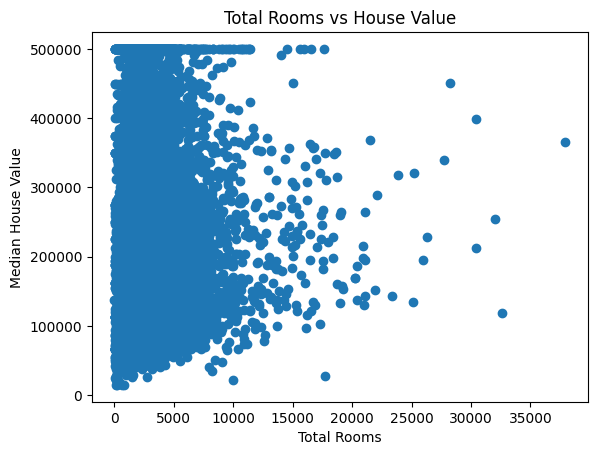

In [3]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['total_rooms'], df['median_house_value'])
plt.title("Total Rooms vs House Value")
plt.xlabel("Total Rooms")
plt.ylabel("Median House Value")
plt.show()

**Seaborn Scatterplot**

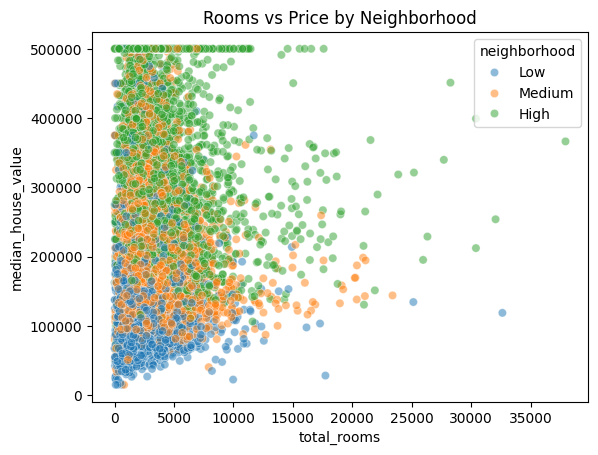

In [4]:
import seaborn as sns

plt.figure()
sns.scatterplot(
    data=df,
    x='total_rooms',
    y='median_house_value',
    hue='neighborhood',
    alpha=0.5
)

plt.title("Rooms vs Price by Neighborhood")
plt.show()

Seaborn automatically handles styling, colors, and grouping, which makes plots easier to read compared to matplotlib. It also allows us to map variables like neighborhood directly to colors without extra code.

Transparency is useful because many points overlap in the scatterplot. By lowering the alpha, we can see dense areas more clearly instead of having points completely cover each other.

**B. Small Multiples**

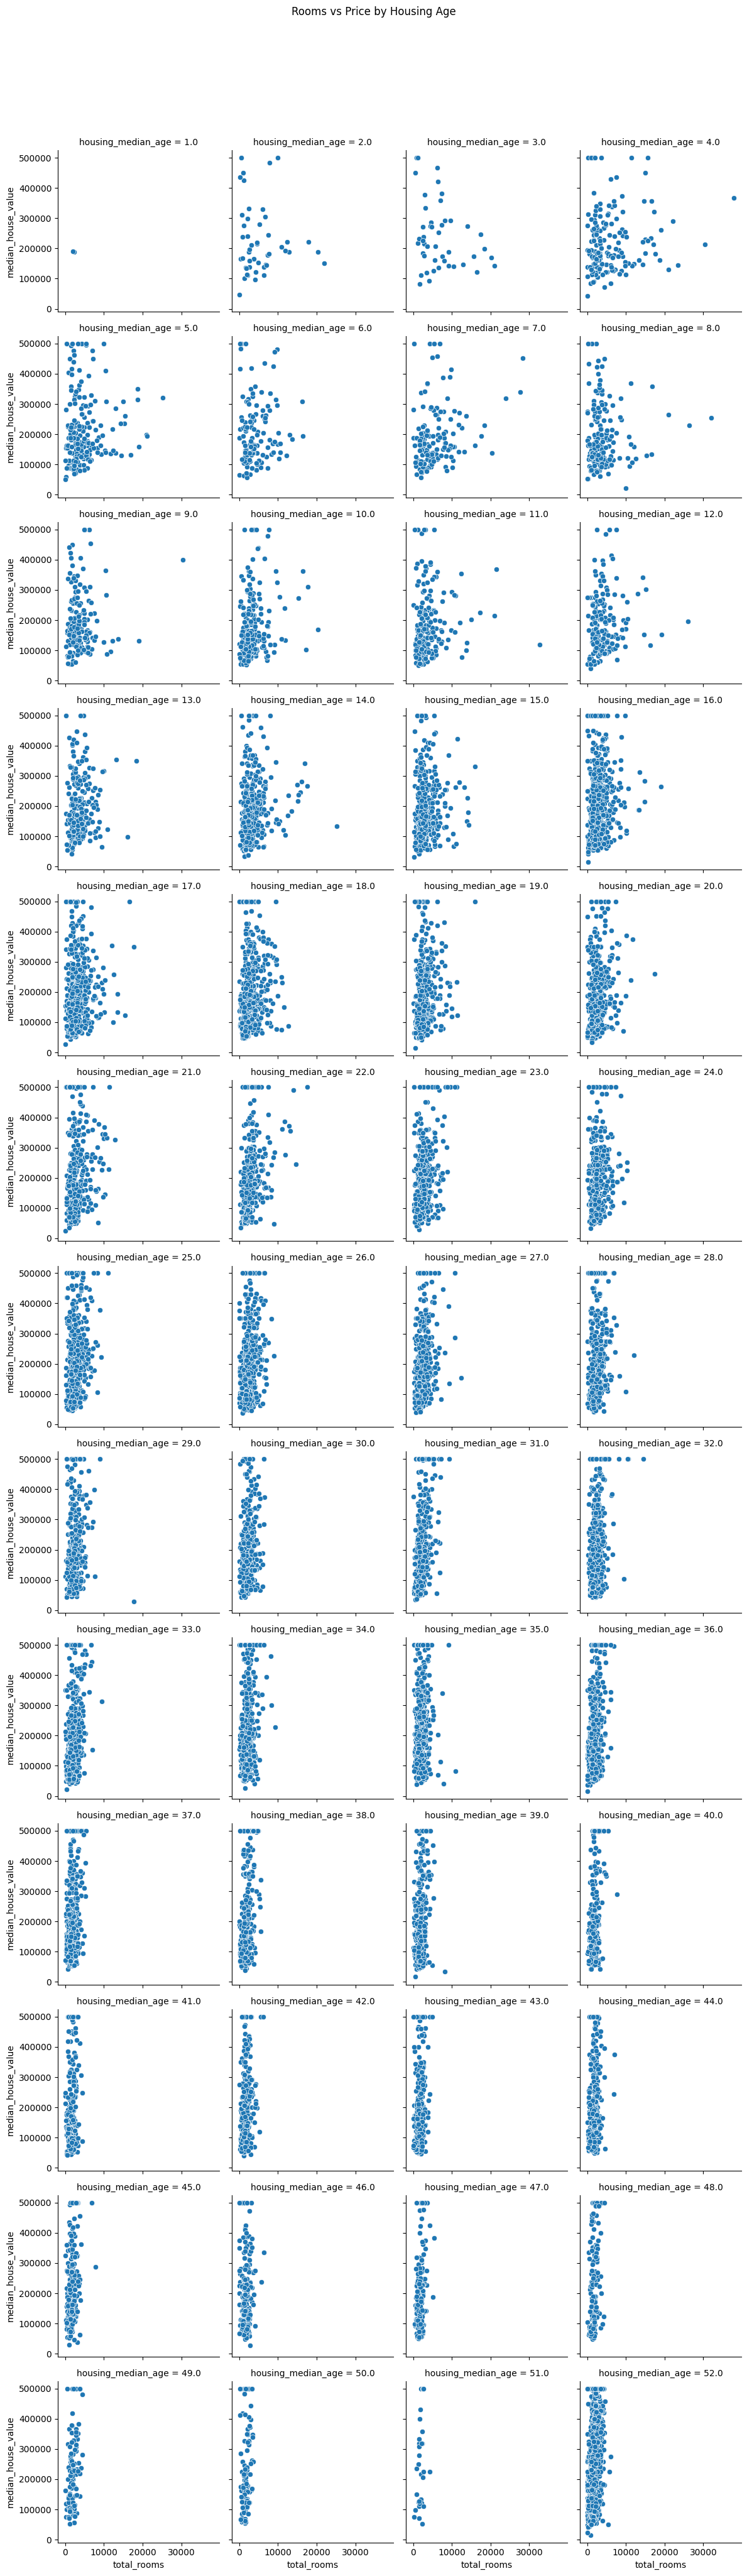

In [5]:
g = sns.FacetGrid(df, col="housing_median_age", col_wrap=4)
g.map_dataframe(sns.scatterplot, x="total_rooms", y="median_house_value")

g.fig.suptitle("Rooms vs Price by Housing Age", y=1.05)
plt.show()

The relationship between rooms and price looks generally positive across groups. However, the strength of the relationship varies slightly depending on housing age.

**C. Distribution + Categorical Plots**

**Histogram**

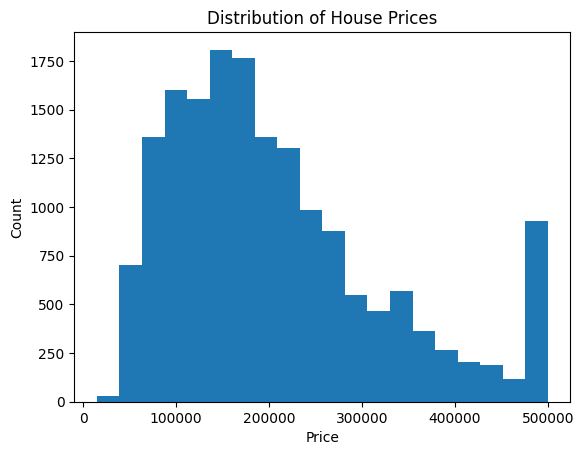

In [6]:
plt.figure()
plt.hist(df['median_house_value'], bins=20)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

**Density Plot**

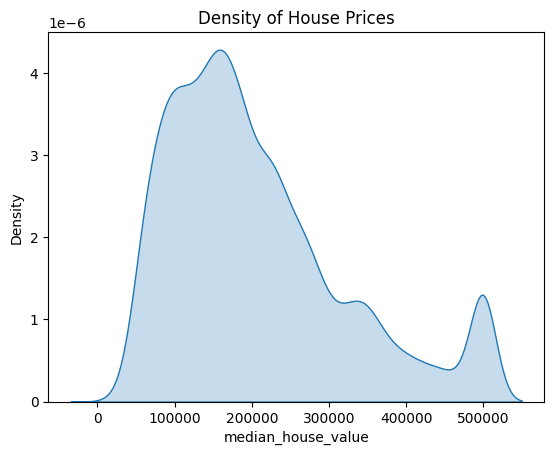

In [7]:
sns.kdeplot(df['median_house_value'], fill=True)
plt.title("Density of House Prices")
plt.show()

**Boxplot by Neighborhood**

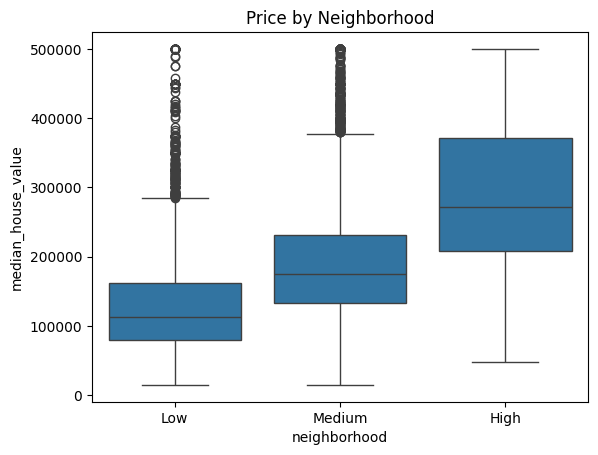

In [8]:
sns.boxplot(x='neighborhood', y='median_house_value', data=df)
plt.title("Price by Neighborhood")
plt.show()

Yes, neighborhoods differ in price. The boxplot shows that the high-income group has higher median prices and a wider spread. This suggests that income level (used as a proxy for neighborhood) strongly affects housing prices.

##**Part II – Linear Regression for Inference**

**A. Multiple Regression (statsmodels)**

In [9]:
import statsmodels.formula.api as smf

model = smf.ols(
    "median_house_value ~ total_rooms + housing_median_age + C(neighborhood)",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.390
Method:                 Least Squares   F-statistic:                     2716.
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        23:09:25   Log-Likelihood:            -2.1816e+05
No. Observations:               17000   AIC:                         4.363e+05
Df Residuals:                   16995   BIC:                         4.364e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

**B. Interpretation**

The coefficient on total_rooms shows how much house value changes when the number of rooms increases, while holding housing age and neighborhood constant.

Total rooms is statistically significant if the p-value is less than 0.05, which means it has a real effect on house price.

R² tells us how much of the variation in house prices is explained by the model. A higher R² means the model fits the data better.

**Part III – Prediction Workflow**

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[['total_rooms', 'housing_median_age']]
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_sk = LinearRegression()
model_sk.fit(X_train, y_train)

y_pred = model_sk.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 114510.42579142038
R²: 0.04835023698202989


Scikit-learn does not report p-values because it focuses on prediction, not statistical inference.

For explanation, I would use statsmodels because it gives detailed statistics like p-values.

For prediction, I would use scikit-learn because it is better for making accurate predictions on new data. These are different goals because one focuses on understanding relationships, while the other focuses on performance.

**Part IV – Integrated Figure**

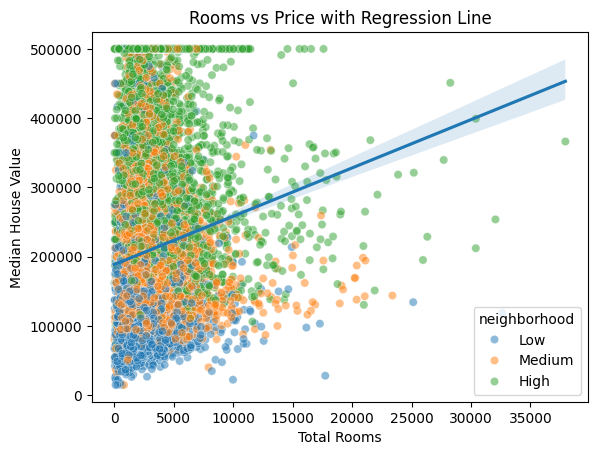

In [11]:
plt.figure()

sns.scatterplot(
    data=df,
    x='total_rooms',
    y='median_house_value',
    hue='neighborhood',
    alpha=0.5
)

sns.regplot(
    data=df,
    x='total_rooms',
    y='median_house_value',
    scatter=False
)

plt.title("Rooms vs Price with Regression Line")
plt.xlabel("Total Rooms")
plt.ylabel("Median House Value")

plt.show()

**Reflection**

The regression model matches what I observed in the visualization. The scatterplot already showed a positive relationship between rooms and price, and the regression line confirms this trend.

The visualization helped me understand the data before building the model, especially seeing how points were distributed. It also showed that income-based neighborhoods affect price, which helped explain the regression results.